# Introduction and Problem Context

Urban mobility is a central sustainability challenge in European cities. Congestion, transport-related emissions, unequal access to services, and strong differences in daily movement patterns across neighborhoods all affect quality of life and the environmental performance of cities. These patterns are often hidden when mobility is summarized only through city-wide averages or simple aggregates. For example, two areas may show similar total activity over a day while serving very different urban functions—one may be primarily residential, while another may act as a business or transport hub. Grouping urban zones based on their temporal activity patterns can therefore reveal meaningful structures that are not visible in aggregate statistics.

This project focuses on **Milan**, using anonymized and spatially aggregated mobile communication activity as a proxy for urban dynamics. The aim is to identify groups of grid cells that share similar daily and weekly activity rhythms. From a sustainability perspective, this can support a better understanding of how different parts of the city are used, and help inform more efficient, context-sensitive mobility planning.

### Use Case & Beneficiaries

The main beneficiaries of this analysis are **urban planners, transport authorities, and local policymakers**. More indirectly, residents and commuters may also benefit if the resulting insights support better mobility services and more equitable urban interventions.

Cluster-based insights could help:
- identify areas with similar functional roles (e.g., residential, commercial, nightlife, or transit-oriented zones),
- support more targeted transport planning and infrastructure investment,
- improve allocation of public resources across neighborhoods,
- provide a basis for monitoring how urban activity patterns change over time.

### Why Clustering?

Clustering is appropriate because this problem does not come with reliable predefined labels for urban zone types. The goal is not to predict a known outcome, but to **discover hidden groupings** in the temporal activity patterns of different parts of the city. Unsupervised learning is therefore a natural choice.

The expected insights are not individual-level predictions, but **latent urban profiles**—for example, zones with strong commuting peaks, mixed-use areas with steady daytime activity, or nightlife-oriented zones with evening intensity. These kinds of patterns are difficult to detect through averages alone, but may emerge clearly when similar zones are grouped together.

### Problem Statement & Hypothesis

**Problem statement:**  
City-wide averages of telecom activity obscure important local differences in how urban space is used. This project applies clustering to anonymized mobile communication data from Milan in order to uncover distinct types of urban zones based on their temporal activity signatures and to explore how these patterns can support sustainable mobility planning.

**Initial hypothesis:**  
I expect the data to contain a small number of interpretable cluster types, such as residential areas, business/commercial districts, transport hubs, and leisure or nightlife zones. If such a structure is found, the approach could potentially generalize to other cities or to larger urban mobility datasets where high-frequency, spatially aggregated activity data are available.

# Import Libraries and Data

In [2]:
import pandas as pd
from pathlib import Path

In [3]:
# Define the column names for the dataset from the provided documentation

cols = [
    "square_id",
    "time_interval",
    "country_code",
    "sms_in",
    "sms_out",
    "call_in",
    "call_out",
    "internet_traffic",
]


# check and define raw directory

raw_dir = Path("../data/raw")
files = sorted(raw_dir.glob("sms-call-internet-mi-*.txt"))

print("Raw dir:", raw_dir.resolve())
print("Number of files found:", len(files))
print("First 5 files:", [f.name for f in files[:5]])
print("Last 5 files:", [f.name for f in files[-5:]])

Raw dir: C:\Users\Lu\OneDrive\ToU\chl_Clustering\data\raw
Number of files found: 62
First 5 files: ['sms-call-internet-mi-2013-11-01.txt', 'sms-call-internet-mi-2013-11-02.txt', 'sms-call-internet-mi-2013-11-03.txt', 'sms-call-internet-mi-2013-11-04.txt', 'sms-call-internet-mi-2013-11-05.txt']
Last 5 files: ['sms-call-internet-mi-2013-12-28.txt', 'sms-call-internet-mi-2013-12-29.txt', 'sms-call-internet-mi-2013-12-30.txt', 'sms-call-internet-mi-2013-12-31.txt', 'sms-call-internet-mi-2014-01-01.txt']


Number of files = 62 is all files from https://dataverse.harvard.edu/dataset.xhtml?persistentId=doi%3A10.7910%2FDVN%2FEGZHFV&. 

In [4]:
# Load the dataset from all the txt files in ../data/raw/

dfs = []

for i, fp in enumerate(files, start=1):
    tmp = pd.read_csv(
        fp,
        sep="\t",
        header=None,
        names=cols,
        na_values=["", " "],
        low_memory=False,
    )
    tmp["source_file"] = fp.name
    dfs.append(tmp)

    # small progress ping every ~10 files
    if i % 10 == 0 or i == len(files):
        print(f"Loaded {i}/{len(files)} files; rows so far ~ {sum(len(d) for d in dfs):,}")

df_all = pd.concat(dfs, ignore_index=True)

print("\nFinal shape:", df_all.shape)
df_all.head()

Loaded 10/62 files; rows so far ~ 53,325,752
Loaded 20/62 files; rows so far ~ 107,602,976
Loaded 30/62 files; rows so far ~ 160,108,003
Loaded 40/62 files; rows so far ~ 211,617,440
Loaded 50/62 files; rows so far ~ 264,406,092
Loaded 60/62 files; rows so far ~ 309,998,087
Loaded 62/62 files; rows so far ~ 319,896,289

Final shape: (319896289, 9)


,square_id,time_interval,country_code,sms_in,sms_out,call_in,call_out,internet_traffic,source_file
0,1,1383260400000,0,0.081363,NaN,NaN,NaN,NaN,sms-call-internet-mi-2013-11-01.txt
1,1,1383260400000,39,0.141864,0.156787,0.160938,0.052275,11.028366,sms-call-internet-mi-2013-11-01.txt
2,1,1383261000000,0,0.136588,NaN,NaN,0.027300,NaN,sms-call-internet-mi-2013-11-01.txt
3,1,1383261000000,33,NaN,NaN,NaN,NaN,0.026137,sms-call-internet-mi-2013-11-01.txt
4,1,1383261000000,39,0.278452,0.119926,0.188777,0.133637,11.100963,sms-call-internet-mi-2013-11-01.txt


# Dataset Modifications & Analysis

In [5]:
# Convert the time_interval from milliseconds to datetime for easier analysis
df_all["datetime"] = pd.to_datetime(df_all["time_interval"], unit="ms")

print("Files loaded:", df_all["source_file"].nunique())
print("Datetime range:", df_all["datetime"].min(), "→", df_all["datetime"].max())

Files loaded: 62
Datetime range: 2013-10-31 23:00:00 → 2014-01-01 22:50:00


According to the documentation, the column `country_code` is the international phone country code of a nation, and it is used to attribute the activity in that row to communications with that nation. Importantly, its meaning depends on the direction/type of activity:

- SMS-in: received SMS in that Milan grid cell/time interval sent from the nation identified by country_code

- SMS-out: sent SMS in that cell/time interval received in the nation identified by country_code

- Call-in: received calls in that cell/time interval issued from the nation identified by country_code

- Call-out: outgoing calls in that cell/time interval received in the nation identified by country_code

- Internet traffic: internet activity in that cell/time interval initiated by users from the nation identified by country_code

Since for my research problem the column `country_code` is not needed, I will cumulate the activities onto the pairs of `square_id` & `time_interval` and drop the column `country_code`.

In [6]:
# check column datatypes 
print("\nColumn dtypes:")
print(df_all.dtypes)


Column dtypes:
square_id                    int64
time_interval                int64
country_code                 int64
sms_in                     float64
sms_out                    float64
call_in                    float64
call_out                   float64
internet_traffic           float64
source_file                    str
datetime            datetime64[ms]
dtype: object


In [7]:
activity_cols = ["sms_in", "sms_out", "call_in", "call_out", "internet_traffic"]

# ensure activity columns are numeric
df_all[activity_cols] = df_all[activity_cols].apply(pd.to_numeric, errors="coerce")

df_agg = (
    df_all
    .groupby(["square_id", "time_interval"], as_index=False)[activity_cols]
    .sum(min_count=1)  # keeps NaN if *all* values are NaN within a group
)

# Recreate datetime after aggregation (recommended)
df_agg["datetime"] = pd.to_datetime(df_agg["time_interval"], unit="ms")

print(df_agg.shape)
df_agg.head()

(89245318, 8)


,square_id,time_interval,sms_in,sms_out,call_in,call_out,internet_traffic,datetime
0,1,1383260400000,0.223227,0.156787,0.160938,0.052275,11.028366,2013-10-31 23:00:00
1,1,1383261000000,0.415040,0.119926,0.188777,0.160938,11.127101,2013-10-31 23:10:00
2,1,1383261600000,0.384079,0.170952,0.134176,0.054601,10.892771,2013-10-31 23:20:00
3,1,1383262200000,0.707572,0.220815,0.027300,0.053438,8.622425,2013-10-31 23:30:00
4,1,1383262800000,0.270679,0.192891,0.053438,0.080738,8.009927,2013-10-31 23:40:00


In [8]:
# move 'datetime' to 3rd column (index 2) for better readability
dt = df_agg.pop("datetime")
df_agg.insert(2, "datetime", dt)

In [9]:
# check missing values
print("\nMissingness (fraction):")
print((df_agg.isna().mean()).sort_values(ascending=False).head(10))


Missingness (fraction):
call_in             0.169750
call_out            0.144731
sms_out             0.102330
sms_in              0.099302
internet_traffic    0.001320
datetime            0.000000
square_id           0.000000
time_interval       0.000000
dtype: float64


I couldn’t find an explicit statement in the primary dataset paper that says “empty fields must be treated as zero.” However, a lot of other data scientists who worked with this data handled NaN as "no activity" and since the numbers of NaNs is so high and would make working with the dataset impossible, I will treat NaN as 0 activity, too.

In [10]:
df_agg[activity_cols] = df_agg[activity_cols].fillna(0)

# quick check
print(df_agg[activity_cols].isna().sum())
df_agg.head()

sms_in              0
sms_out             0
call_in             0
call_out            0
internet_traffic    0
dtype: int64


,square_id,time_interval,datetime,sms_in,sms_out,call_in,call_out,internet_traffic
0,1,1383260400000,2013-10-31 23:00:00,0.223227,0.156787,0.160938,0.052275,11.028366
1,1,1383261000000,2013-10-31 23:10:00,0.415040,0.119926,0.188777,0.160938,11.127101
2,1,1383261600000,2013-10-31 23:20:00,0.384079,0.170952,0.134176,0.054601,10.892771
3,1,1383262200000,2013-10-31 23:30:00,0.707572,0.220815,0.027300,0.053438,8.622425
4,1,1383262800000,2013-10-31 23:40:00,0.270679,0.192891,0.053438,0.080738,8.009927


In [11]:
# check duplicates on the true key (should be rare; if present, it's worth checking)
key = ["square_id", "time_interval"]
dup_rate = df_agg.duplicated(key).mean()
print(f"\nExact duplicates on (square_id,time_interval): {dup_rate:.6f}")


Exact duplicates on (square_id,time_interval): 0.000000


# Add x,y coordinates for later visualisation

From the dataset we know how the grid looks like:

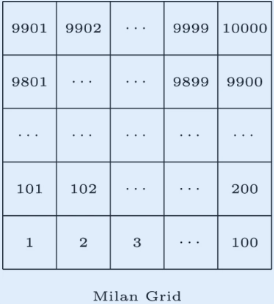

In [12]:
n_cols = 100

# square_id starts at 1
df_agg["x"] = ((df_agg["square_id"] - 1) % n_cols) + 1
df_agg["y"] = ((df_agg["square_id"] - 1) // n_cols) + 1

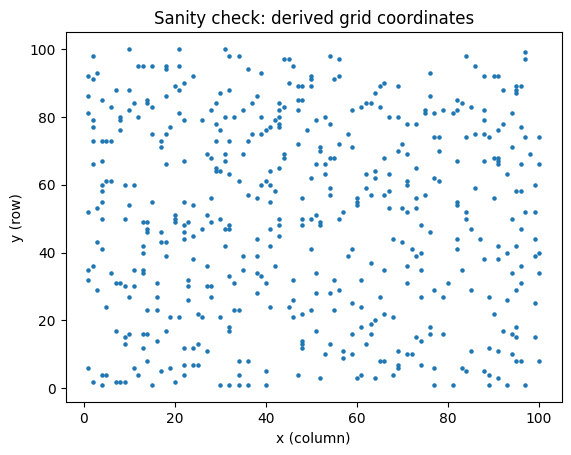

In [14]:
import matplotlib.pyplot as plt

sample = df_agg.drop_duplicates("square_id")[["square_id", "x", "y"]].sample(500, random_state=42)

plt.figure()
plt.scatter(sample["x"], sample["y"], s=5)
plt.title("Sanity check: derived grid coordinates")
plt.xlabel("x (column)")
plt.ylabel("y (row)")
plt.show()

# Save dataframe to processed file

I am going to save the df into a Parquet file, since the dataset is so big.

In [19]:
processed_dir = Path("../data/processed")
processed_dir.mkdir(parents=True, exist_ok=True)

out_path = processed_dir / "milan_telecom_agg_all.parquet"
df_agg.to_parquet(out_path, index=False, engine="pyarrow", compression="snappy")

print("Saved:", out_path.resolve())
print("Parquet size (MB):", out_path.stat().st_size / (1024 * 1024))

Saved: C:\Users\Lu\OneDrive\ToU\chl_Clustering\data\processed\milan_telecom_agg_all.parquet
Parquet size (MB): 2871.608124732971


We will move on in notebook 02_EDA.ipynb